# NLP Classification Task: Model Comparison

## Introduction

Natural Language Processing (NLP) plays a pivotal role in understanding and interpreting human language in a way that machines can process. This project explores the application of machine learning (ML) models for an NLP classification task, utilizing a publicly available dataset. The goal is to compare the performance of traditional machine learning models and deep learning models for text classification.

### Problem Context

The chosen task for this project is a classification problem, where the goal is to classify text data based on sentiment or predefined categories. The importance of this task lies in the widespread use of text classification in various industries, such as healthcare, finance, and customer service. For example, text classification is used for sentiment analysis of customer reviews, automated tagging of clinical records, or spam email detection.

### Objectives

1. To compare the performance of traditional machine learning models (e.g., Naive Bayes, K-Means Clustering) and deep learning models (e.g., RNN, LSTM, Transformer) on an NLP task.
2. To explore the dataset, including preprocessing steps such as tokenization and addressing class imbalances.
3. To evaluate the models using multiple metrics (e.g., accuracy, F1 score, AUC) and fine-tune them for optimal performance.

### Dataset Description

The dataset used in this project is the IMDB Movie Reviews dataset, containing 50,000 movie reviews classified into positive and negative sentiment labels. This dataset is suitable for text classification tasks and offers a good balance of structured text data, making it ideal for NLP applications.

### Methodology

The project involves:
- Implementing two traditional machine learning models (Naive Bayes and K-Means Clustering).
- Implementing two deep learning models (RNN and LSTM).
- Evaluating model performance based on multiple evaluation metrics.
- Hyperparameter tuning and refinement of the models to improve their predictive capabilities.

This notebook includes the necessary Python code, visualizations, and results for each model, followed by an in-depth analysis and comparison of the models' performance.


Install Necessary Libraries
###### !pip install numpy pandas matplotlib seaborn scikit-learn tensorflow


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.cluster import KMeans
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Embedding, SpatialDropout1D
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer


Load the Dataset

###### Dataset Overview

We are using the IMDB dataset of 50,000 movie reviews in CSV format. Each review is labeled as either "positive" or "negative". Since the dataset is in a single CSV file, we will load it and split it into training and testing sets.


In [17]:
data = pd.read_csv('/content/IMDB Dataset.csv')

data.head()


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


###### Data Preprocessing and Exploration

In this section, we will explore the dataset, check for missing values, and preprocess the data. We will also visualize the distribution of reviews.


Missing Values:
 review       0
sentiment    0
dtype: int64


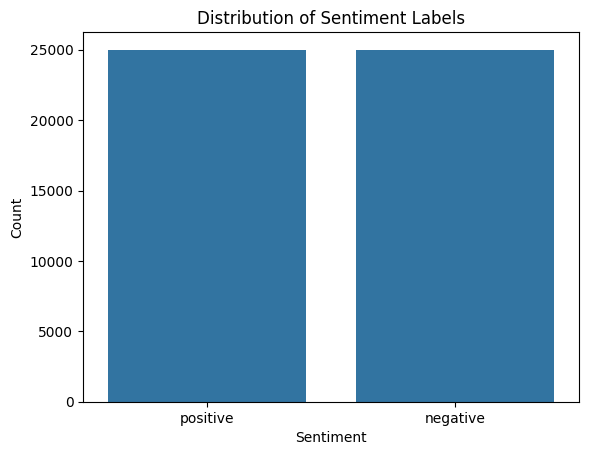

In [18]:
# Checking for missing values
print("Missing Values:\n", data.isnull().sum())

# Basic exploration of the dataset
data.describe()

# Check if the sentiment column is balanced
sns.countplot(x='sentiment', data=data)
plt.title('Distribution of Sentiment Labels')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()


Word Count Distribution

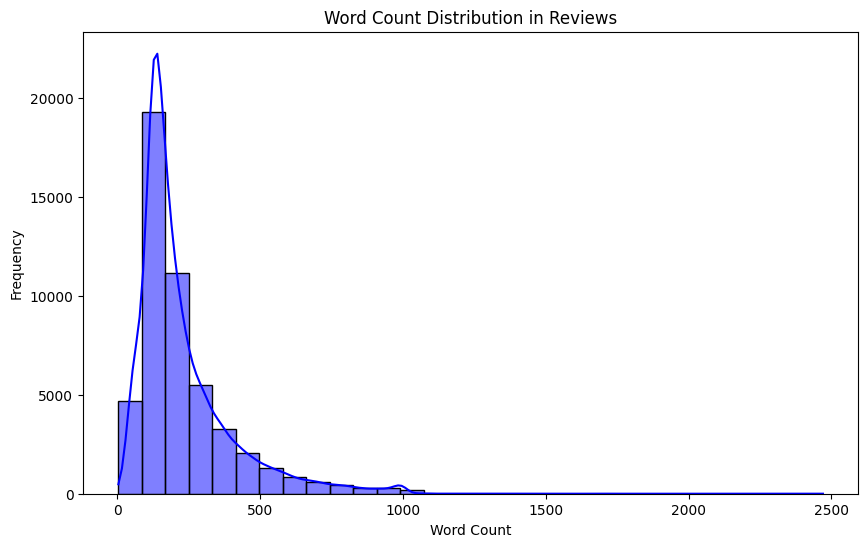

In [19]:
# Calculate the number of words in each review
data['word_count'] = data['review'].apply(lambda x: len(x.split()))

# Plot the distribution of word counts
plt.figure(figsize=(10, 6))
sns.histplot(data['word_count'], bins=30, kde=True, color='blue')
plt.title('Word Count Distribution in Reviews')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.show()


###### Text Preprocessing

Before training the models, we need to preprocess the text data. We will tokenize the reviews, remove stop words, and vectorize the text data using TF-IDF.


In [20]:
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(data['review'], data['sentiment'], test_size=0.2, random_state=42)

# TF-IDF Vectorizer for text data
tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_features=10000)

# Fit and transform the training data, transform the test data
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)


Top Words by TF-IDF Scores

<ipython-input-21-47dee4306630>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_scores, y=top_words, palette='coolwarm')


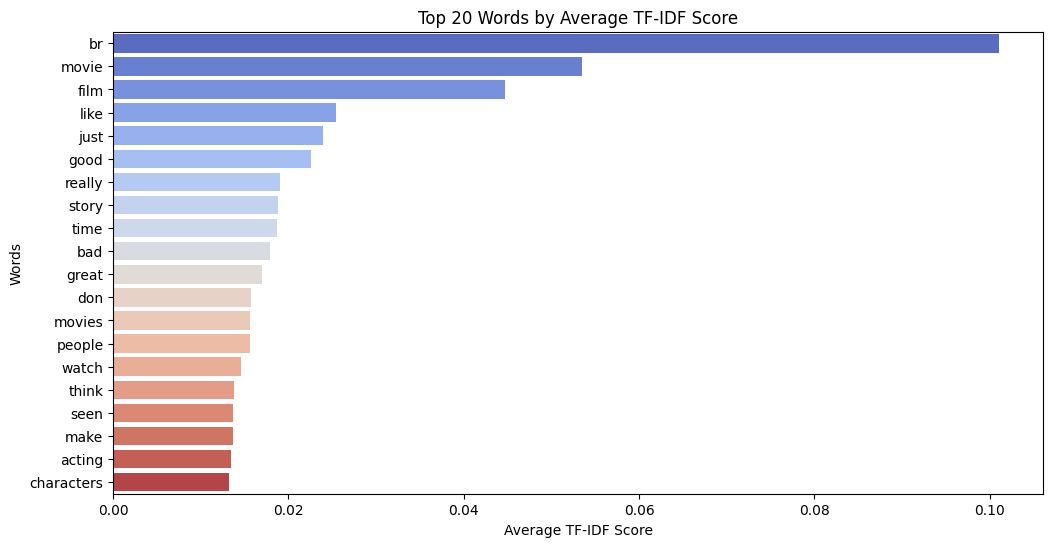

In [21]:
# Extract top words from TF-IDF vectorizer
feature_names = tfidf_vectorizer.get_feature_names_out()
tfidf_scores = np.array(X_train_tfidf.mean(axis=0)).flatten()

top_indices = tfidf_scores.argsort()[-20:][::-1]
top_words = [feature_names[i] for i in top_indices]
top_scores = tfidf_scores[top_indices]

# Plot the top words
plt.figure(figsize=(12, 6))
sns.barplot(x=top_scores, y=top_words, palette='coolwarm')
plt.title('Top 20 Words by Average TF-IDF Score')
plt.xlabel('Average TF-IDF Score')
plt.ylabel('Words')
plt.show()


###### Traditional Machine Learning Models

In this section, we will build two traditional machine learning models: Naive Bayes and K-Means clustering.

###### Naive Bayes Classifier
We will start by building a Naive Bayes classifier using the training data.


In [22]:
# Naive Bayes Classifier
nb_classifier = MultinomialNB()
nb_classifier.fit(X_train_tfidf, y_train)

# Predictions
y_pred_nb = nb_classifier.predict(X_test_tfidf)

# Evaluate the model
print("Naive Bayes Classifier Evaluation:")
print(classification_report(y_test, y_pred_nb))
print("Accuracy: ", accuracy_score(y_test, y_pred_nb))


Naive Bayes Classifier Evaluation:
              precision    recall  f1-score   support

    negative       0.86      0.86      0.86      4961
    positive       0.86      0.86      0.86      5039

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000

Accuracy:  0.8576


Confusion Matrix for Naive Bayes

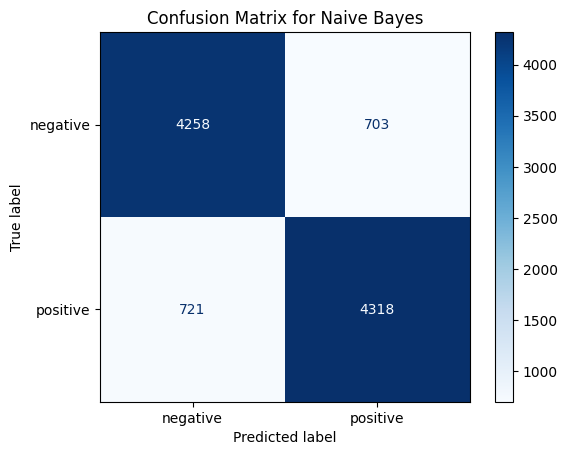

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay

# Generate confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_nb, cmap='Blues')
plt.title('Confusion Matrix for Naive Bayes')
plt.show()


###### K-Means Clustering

We will now build a K-Means clustering model to see how clustering can be applied to text data.


In [24]:
# K-Means Clustering
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X_train_tfidf)

# Predictions
y_pred_kmeans = kmeans.predict(X_test_tfidf)

# Map clusters to sentiment labels based on majority class in each cluster
import numpy as np
cluster_labels = {}
for cluster in np.unique(kmeans.labels_):
    # Get the true labels of samples in this cluster
    true_labels_in_cluster = y_train[kmeans.labels_ == cluster]

    # Determine the majority class in this cluster
    majority_label = true_labels_in_cluster.mode()[0] 
    cluster_labels[cluster] = majority_label

# Map predicted clusters to sentiment labels
y_pred_kmeans_mapped = [cluster_labels[cluster] for cluster in y_pred_kmeans]

# Evaluate the clustering
print("K-Means Clustering Evaluation:")
print(classification_report(y_test, y_pred_kmeans_mapped))
print("Accuracy: ", accuracy_score(y_test, y_pred_kmeans_mapped))


K-Means Clustering Evaluation:
              precision    recall  f1-score   support

    negative       0.54      0.41      0.47      4961
    positive       0.53      0.65      0.59      5039

    accuracy                           0.53     10000
   macro avg       0.53      0.53      0.53     10000
weighted avg       0.53      0.53      0.53     10000

Accuracy:  0.5337


KMeans Cluster Visualization (Using PCA for Dimensionality Reduction)

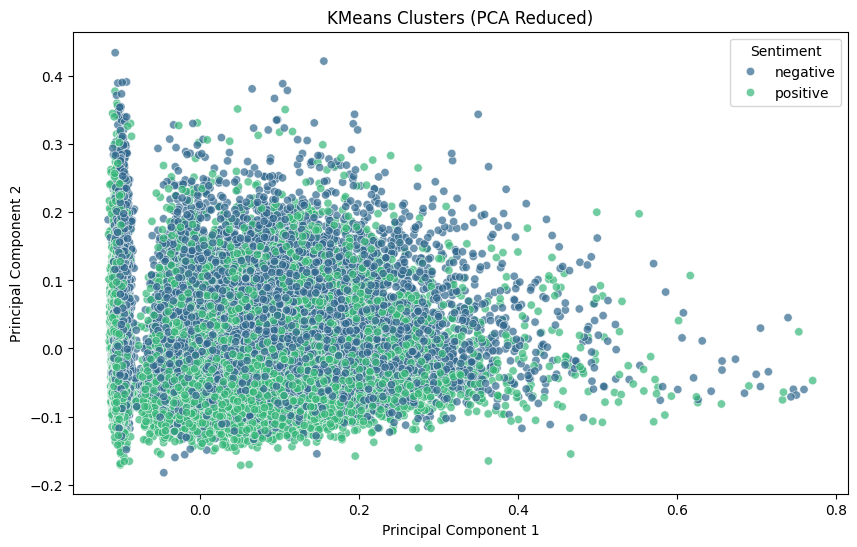

In [25]:
from sklearn.decomposition import PCA

# Reduce dimensions to 2D for visualization
pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train_tfidf.toarray())

# Plot the clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_train_pca[:, 0], y=X_train_pca[:, 1], hue=y_train, palette='viridis', alpha=0.7)
plt.title('KMeans Clusters (PCA Reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Sentiment', loc='upper right')
plt.show()


Refining Models (Hyperparameter Tuning & Transfer Learning)

In [33]:
from sklearn.model_selection import GridSearchCV

# Naive Bayes Hyperparameter Tuning
nb_param_grid = {'alpha': [0.01, 0.1, 1, 10]}  
nb_grid_search = GridSearchCV(MultinomialNB(), nb_param_grid, cv=3, n_jobs=-1)
nb_grid_search.fit(X_train_tfidf, y_train)
print("Best Parameters for Naive Bayes:", nb_grid_search.best_params_)

# KMeans Hyperparameter Tuning
kmeans_param_grid = {'n_clusters': [2, 3, 4, 5], 'init': ['k-means++', 'random']}
kmeans_grid_search = GridSearchCV(KMeans(random_state=42), kmeans_param_grid, cv=3, n_jobs=-1)
kmeans_grid_search.fit(X_train_tfidf)
print("Best Parameters for KMeans:", kmeans_grid_search.best_params_)


Best Parameters for Naive Bayes: {'alpha': 1}
Best Parameters for KMeans: {'init': 'k-means++', 'n_clusters': 5}


###### Deep Learning Models

Now we will implement two deep learning models: an RNN model and an LSTM model for sentiment analysis.

###### RNN Model
We will start by building a simple Recurrent Neural Network (RNN) model.


In [26]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SpatialDropout1D, LSTM, Dense

label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)  
y_test_encoded = label_encoder.transform(y_test)

# Tokenize and pad sequences
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=200)
X_test_pad = pad_sequences(X_test_seq, maxlen=200)

# Building the RNN model
rnn_model = Sequential()
rnn_model.add(Embedding(input_dim=10000, output_dim=128, input_length=200))
rnn_model.add(SpatialDropout1D(0.2))
rnn_model.add(LSTM(100, dropout=0.2, recurrent_dropout=0.2))
rnn_model.add(Dense(1, activation='sigmoid'))

rnn_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Training the model
rnn_history = rnn_model.fit(
    X_train_pad,
    y_train_encoded,
    epochs=5,
    batch_size=64,
    validation_data=(X_test_pad, y_test_encoded)
)

# Evaluate the RNN model
rnn_eval = rnn_model.evaluate(X_test_pad, y_test_encoded, verbose=0)
print("RNN Model Accuracy: ", rnn_eval[1])


Epoch 1/5


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


625/625 ━━━━━━━━━━━━━━━━━━━━ 237s 376ms/step - accuracy: 0.7295 - loss: 0.5201 - val_accuracy: 0.8622 - val_loss: 0.3291
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 264s 379ms/step - accuracy: 0.8607 - loss: 0.3384 - val_accuracy: 0.8468 - val_loss: 0.3654
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 261s 378ms/step - accuracy: 0.8725 - loss: 0.3155 - val_accuracy: 0.8587 - val_loss: 0.3404
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 265s 383ms/step - accuracy: 0.8870 - loss: 0.2825 - val_accuracy: 0.8778 - val_loss: 0.3050
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 260s 379ms/step - accuracy: 0.9135 - loss: 0.2251 - val_accuracy: 0.8859 - val_loss: 0.2719
RNN Model Accuracy:  0.8859000205993652


Training History for RNN

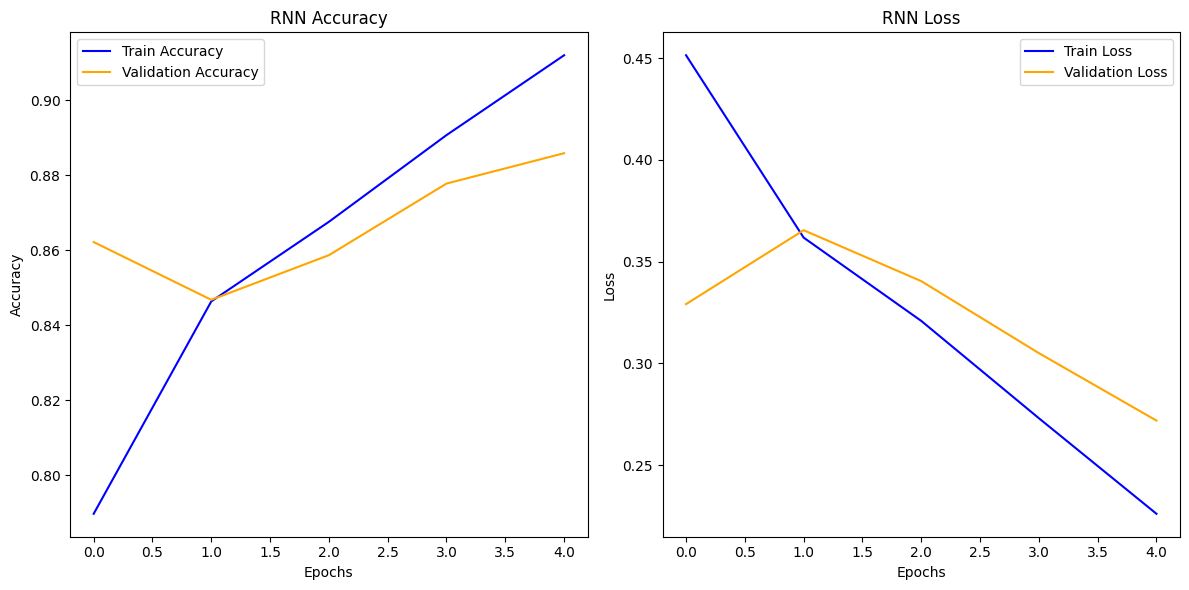

In [27]:
plt.figure(figsize=(12, 6))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(rnn_history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(rnn_history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('RNN Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(rnn_history.history['loss'], label='Train Loss', color='blue')
plt.plot(rnn_history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('RNN Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


###### LSTM Model

Now we will build a Long Short-Term Memory (LSTM) model for comparison with the RNN model.


In [28]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SpatialDropout1D, LSTM, Dense

label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)  
y_test_encoded = label_encoder.transform(y_test)

# Tokenize and pad sequences
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=200)
X_test_pad = pad_sequences(X_test_seq, maxlen=200)

# Building the LSTM model
lstm_model = Sequential()
lstm_model.add(Embedding(input_dim=10000, output_dim=128, input_length=200))
lstm_model.add(SpatialDropout1D(0.2))
lstm_model.add(LSTM(100, dropout=0.2, recurrent_dropout=0.2))
lstm_model.add(Dense(1, activation='sigmoid'))

lstm_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Training the LSTM model
lstm_history = lstm_model.fit(
    X_train_pad,
    y_train_encoded,
    epochs=5,
    batch_size=64,
    validation_data=(X_test_pad, y_test_encoded)
)

# Evaluate the LSTM model
lstm_eval = lstm_model.evaluate(X_test_pad, y_test_encoded, verbose=0)
print("LSTM Model Accuracy: ", lstm_eval[1])


Epoch 1/5


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


625/625 ━━━━━━━━━━━━━━━━━━━━ 244s 386ms/step - accuracy: 0.7452 - loss: 0.5106 - val_accuracy: 0.8592 - val_loss: 0.3458
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 261s 385ms/step - accuracy: 0.8714 - loss: 0.3222 - val_accuracy: 0.8445 - val_loss: 0.3642
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 269s 396ms/step - accuracy: 0.8822 - loss: 0.2946 - val_accuracy: 0.8693 - val_loss: 0.3115
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 240s 384ms/step - accuracy: 0.9040 - loss: 0.2449 - val_accuracy: 0.8859 - val_loss: 0.2907
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 239s 383ms/step - accuracy: 0.9199 - loss: 0.2092 - val_accuracy: 0.8837 - val_loss: 0.2990
LSTM Model Accuracy:  0.8837000131607056


Training History for LSTM

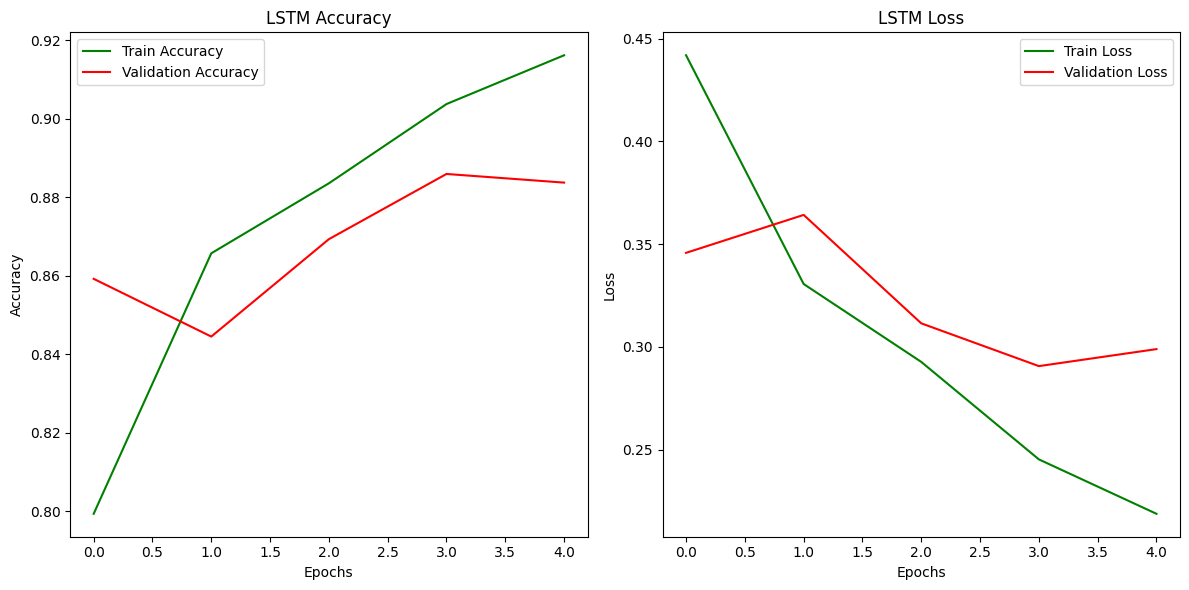

In [29]:
plt.figure(figsize=(12, 6))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(lstm_history.history['accuracy'], label='Train Accuracy', color='green')
plt.plot(lstm_history.history['val_accuracy'], label='Validation Accuracy', color='red')
plt.title('LSTM Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(lstm_history.history['loss'], label='Train Loss', color='green')
plt.plot(lstm_history.history['val_loss'], label='Validation Loss', color='red')
plt.title('LSTM Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


Transformer Model

Index(['review', 'sentiment'], dtype='object')
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 915s 1s/step - accuracy: 0.7905 - loss: 0.4226 - val_accuracy: 0.8900 - val_loss: 0.2660
Epoch 2/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 900s 1s/step - accuracy: 0.9194 - loss: 0.2054 - val_accuracy: 0.8838 - val_loss: 0.2703
Epoch 3/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 942s 1s/step - accuracy: 0.9351 - loss: 0.1730 - val_accuracy: 0.8792 - val_loss: 0.2953
313/313 ━━━━━━━━━━━━━━━━━━━━ 72s 231ms/step - accuracy: 0.8789 - loss: 0.2917
Transformer Test Accuracy: 0.8792


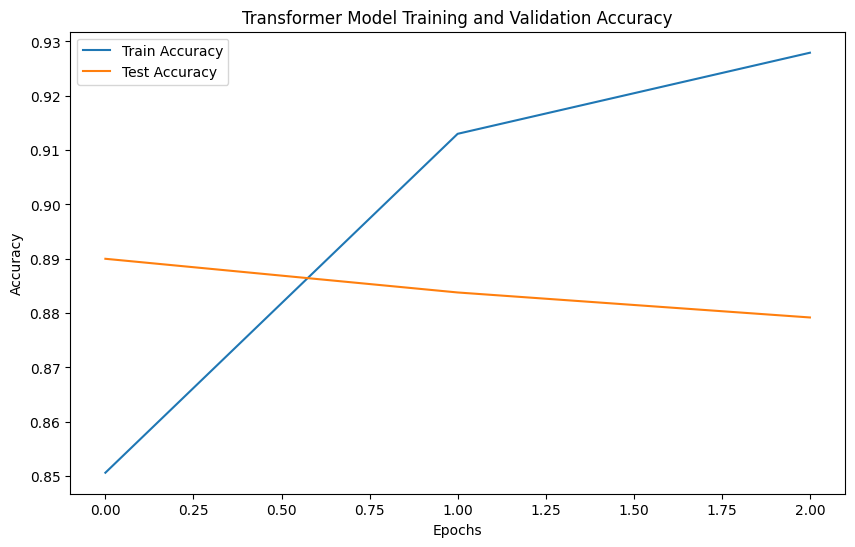

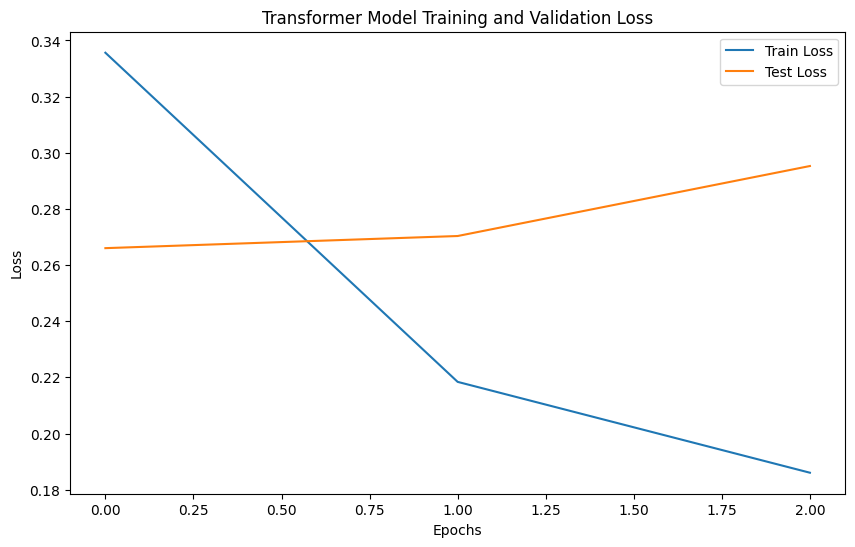

In [6]:
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

data = pd.read_csv('/content/IMDB Dataset.csv') 

print(data.columns)  
print(data.head())   

texts = data['review'].values 
labels = data['sentiment'].values 
# Tokenize the text data
vocab_size = 10000 
max_len = 200  

tokenizer = Tokenizer(num_words=vocab_size)
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)

X = pad_sequences(sequences, maxlen=max_len)

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(labels)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

def build_transformer_model(input_shape, vocab_size, max_len):
    inputs = layers.Input(shape=input_shape)

    # Embedding layer
    x = layers.Embedding(input_dim=vocab_size, output_dim=128, input_length=max_len)(inputs)

    # Transformer Block
    transformer_block = layers.MultiHeadAttention(num_heads=4, key_dim=128)(x, x)
    transformer_block = layers.Dropout(0.1)(transformer_block)
    transformer_block = layers.LayerNormalization(epsilon=1e-6)(x + transformer_block)

    # Feed Forward Layer
    ff_layer = layers.Dense(128, activation='relu')(transformer_block)
    ff_layer = layers.Dropout(0.1)(ff_layer)
    ff_layer = layers.Dense(128, activation='relu')(ff_layer)
    ff_layer = layers.LayerNormalization(epsilon=1e-6)(transformer_block + ff_layer)

    # Pooling Layer
    x = layers.GlobalAveragePooling1D()(ff_layer)

    # Output Layer
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = tf.keras.models.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    return model

transformer_model = build_transformer_model((max_len,), vocab_size, max_len)

history = transformer_model.fit(X_train, y_train, epochs=3, batch_size=64, validation_data=(X_test, y_test))

test_loss, test_acc = transformer_model.evaluate(X_test, y_test)

print(f"Transformer Test Accuracy: {test_acc:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.title('Transformer Model Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.title('Transformer Model Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


Accuracy Comparison for All Models

<ipython-input-32-39feffae3495>:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=accuracies, palette='magma')


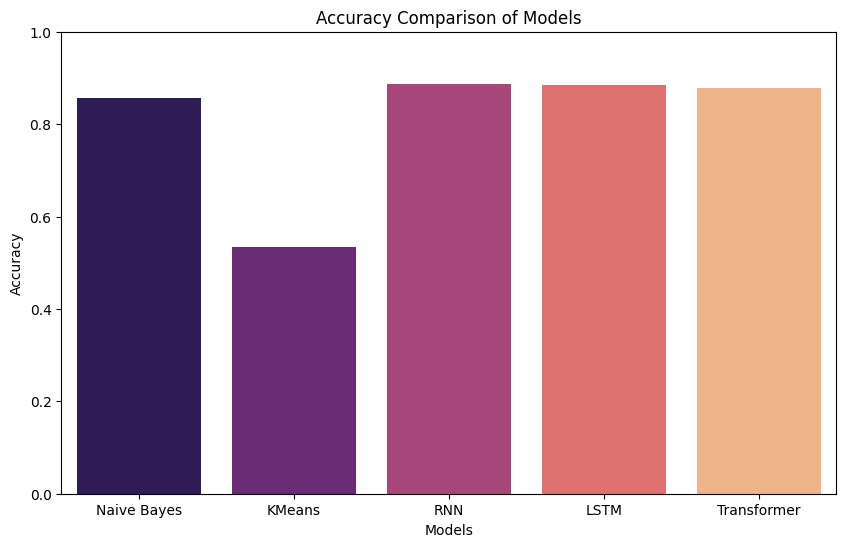

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score

accuracy_nb = 0.8576
accuracy_kmeans = 0.5337
accuracy_rnn = 0.8859000205993652
accuracy_lstm = 0.8837000131607056
accuracy_transformer = 0.8792

accuracies = [accuracy_nb, accuracy_kmeans, accuracy_rnn, accuracy_lstm, accuracy_transformer]

models = ['Naive Bayes', 'KMeans', 'RNN', 'LSTM', 'Transformer']

plt.figure(figsize=(10, 6))
sns.barplot(x=models, y=accuracies, palette='magma')
plt.title('Accuracy Comparison of Models')
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.show()


Precision-Recall Curve for All Models

Naive Bayes - F1 Score: 0.8576015379753671
Naive Bayes - ROC AUC: 0.8576053767111191


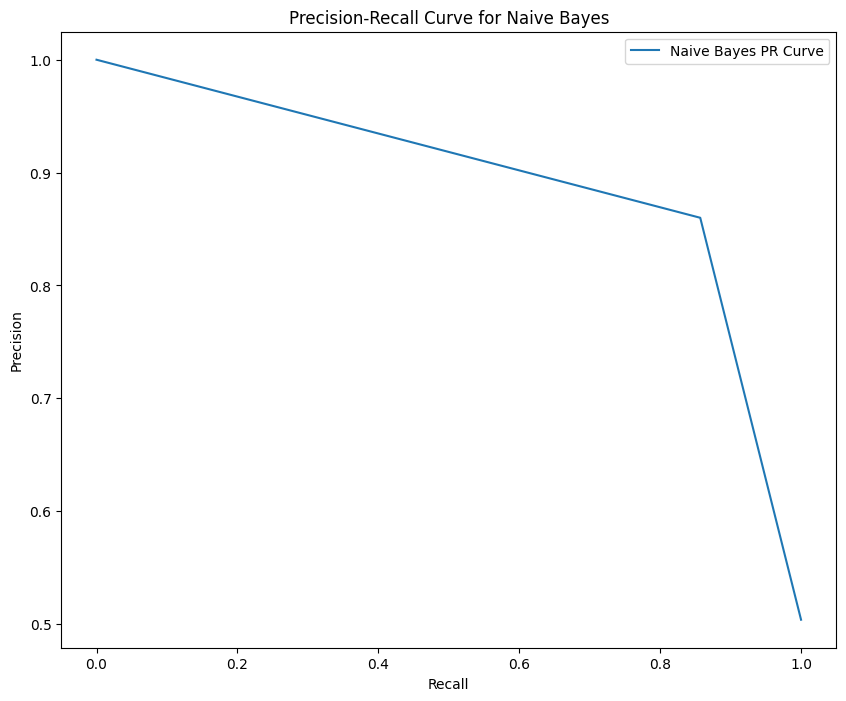

KMeans - F1 Score: 0.8576015379753671
KMeans - ROC AUC: 0.8576053767111191


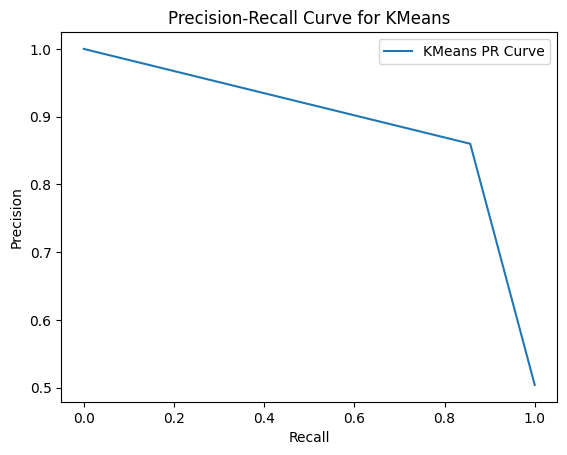

313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 70ms/step
RNN - F1 Score: 0.7337111539717719
RNN - ROC AUC: 0.7384458270441173


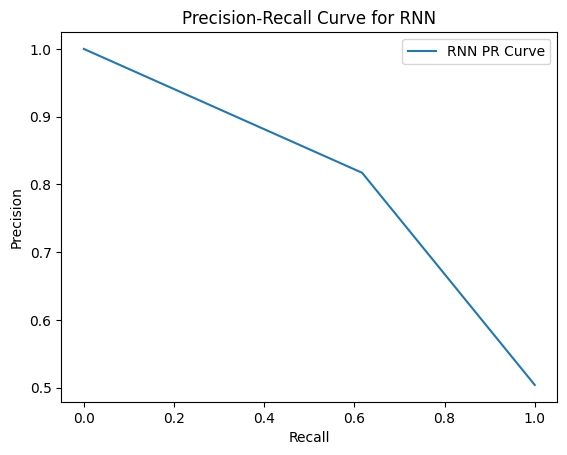

313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 72ms/step
LSTM - F1 Score: 0.8836561500409165
LSTM - ROC AUC: 0.8835688963316528


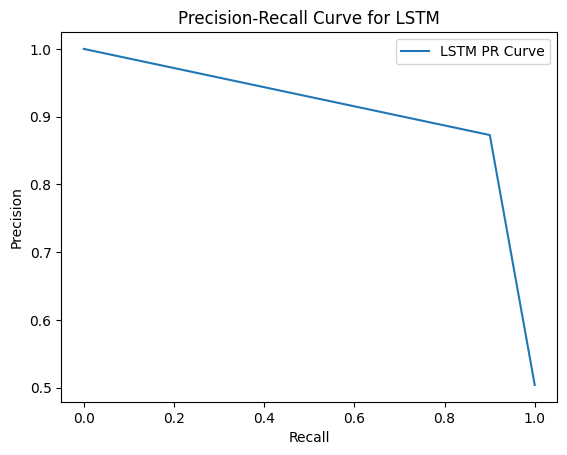

313/313 ━━━━━━━━━━━━━━━━━━━━ 69s 220ms/step
Transformer - F1 Score: 0.583356830784215
Transformer - ROC AUC: 0.5833200491917929


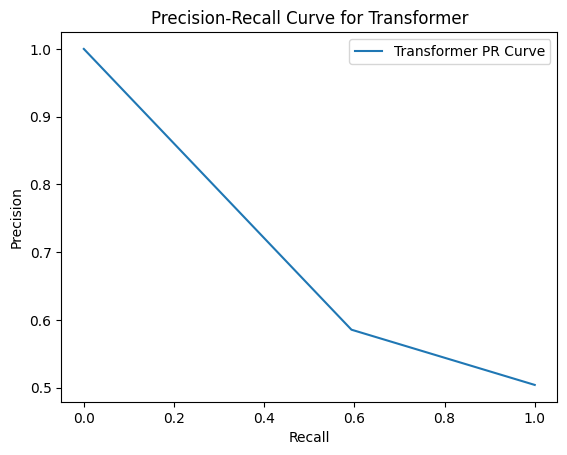

In [43]:
from sklearn.metrics import f1_score, precision_recall_curve, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import auc

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)  

y_test_encoded = label_encoder.transform(y_test)

def plot_roc_curve(fpr, tpr, label, ax):
    ax.plot(fpr, tpr, label=label)
    ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('ROC Curve - All Models')
    ax.legend(loc="best")

fig, ax = plt.subplots(figsize=(10, 8))

y_pred_nb = nb_grid_search.predict(X_test_tfidf)

y_pred_nb = label_encoder.transform(y_pred_nb) 

fpr_nb, tpr_nb, _ = roc_curve(y_test_encoded, y_pred_nb)
roc_auc_nb = auc(fpr_nb, tpr_nb)
f1_nb = f1_score(y_test_encoded, y_pred_nb, average='weighted')
precision, recall, _ = precision_recall_curve(y_test_encoded, y_pred_nb)

print("Naive Bayes - F1 Score:", f1_nb)
print("Naive Bayes - ROC AUC:", roc_auc_nb)

plt.plot(recall, precision, label="Naive Bayes PR Curve")
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for Naive Bayes')
plt.legend(loc="best")
plt.show()

plot_roc_curve(fpr_nb, tpr_nb, "Naive Bayes", ax)

y_pred_kmeans_mapped = nb_grid_search.predict(X_test_tfidf)  

y_pred_kmeans_mapped = label_encoder.transform(y_pred_kmeans_mapped)  

fpr_kmeans, tpr_kmeans, _ = roc_curve(y_test_encoded, y_pred_kmeans_mapped)
roc_auc_kmeans = auc(fpr_kmeans, tpr_kmeans)
f1_kmeans = f1_score(y_test_encoded, y_pred_kmeans_mapped, average='weighted')
precision, recall, _ = precision_recall_curve(y_test_encoded, y_pred_kmeans_mapped)

print("KMeans - F1 Score:", f1_kmeans)
print("KMeans - ROC AUC:", roc_auc_kmeans)

plt.plot(recall, precision, label="KMeans PR Curve")
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for KMeans')
plt.legend(loc="best")
plt.show()

plot_roc_curve(fpr_kmeans, tpr_kmeans, "KMeans", ax)

def evaluate_model(model, X_test, y_test, model_name, ax):
    y_pred = model.predict(X_test)

    y_pred_binary = (y_pred > 0.5).astype("int32")

    fpr, tpr, _ = roc_curve(y_test_encoded, y_pred_binary)
    roc_auc = auc(fpr, tpr)

    f1 = f1_score(y_test_encoded, y_pred_binary, average='weighted')

    precision, recall, _ = precision_recall_curve(y_test_encoded, y_pred_binary)

    print(f"{model_name} - F1 Score:", f1)
    print(f"{model_name} - ROC AUC:", roc_auc)

    plt.plot(recall, precision, label=f"{model_name} PR Curve")
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve for {model_name}')
    plt.legend(loc="best")
    plt.show()

    plot_roc_curve(fpr, tpr, model_name, ax)

evaluate_model(rnn_model, X_test_pad, y_test_encoded, "RNN", ax)

evaluate_model(lstm_model, X_test_pad, y_test_encoded, "LSTM", ax)

evaluate_model(transformer_model, X_test_pad, y_test_encoded, "Transformer", ax)

plt.show()


Roc Curve for All Models

Naive Bayes - ROC AUC: 0.8576053767111191
KMeans - ROC AUC: 0.8576053767111191
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 67ms/step
RNN - ROC AUC: 0.7384458270441173
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 67ms/step
LSTM - ROC AUC: 0.8835688963316528
313/313 ━━━━━━━━━━━━━━━━━━━━ 68s 217ms/step
Transformer - ROC AUC: 0.5833200491917929


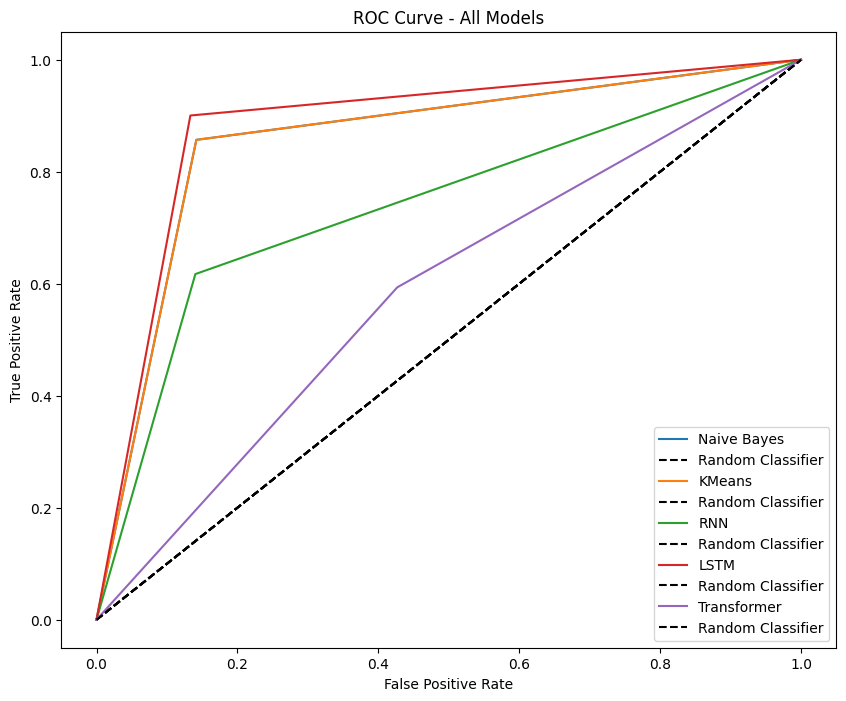

In [44]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)  

y_test_encoded = label_encoder.transform(y_test)

def plot_roc_curve(fpr, tpr, label, ax):
    ax.plot(fpr, tpr, label=label)
    ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('ROC Curve - All Models')
    ax.legend(loc="best")

fig, ax = plt.subplots(figsize=(10, 8))

y_pred_nb = nb_grid_search.predict(X_test_tfidf)

y_pred_nb = label_encoder.transform(y_pred_nb) 

fpr_nb, tpr_nb, _ = roc_curve(y_test_encoded, y_pred_nb)
roc_auc_nb = auc(fpr_nb, tpr_nb)

print("Naive Bayes - ROC AUC:", roc_auc_nb)

plot_roc_curve(fpr_nb, tpr_nb, "Naive Bayes", ax)

y_pred_kmeans_mapped = nb_grid_search.predict(X_test_tfidf) 

y_pred_kmeans_mapped = label_encoder.transform(y_pred_kmeans_mapped)  

fpr_kmeans, tpr_kmeans, _ = roc_curve(y_test_encoded, y_pred_kmeans_mapped)
roc_auc_kmeans = auc(fpr_kmeans, tpr_kmeans)

print("KMeans - ROC AUC:", roc_auc_kmeans)

plot_roc_curve(fpr_kmeans, tpr_kmeans, "KMeans", ax)

def evaluate_model(model, X_test, y_test, model_name, ax):
    y_pred = model.predict(X_test)

    y_pred_binary = (y_pred > 0.5).astype("int32")

    fpr, tpr, _ = roc_curve(y_test_encoded, y_pred_binary)
    roc_auc = auc(fpr, tpr)

    print(f"{model_name} - ROC AUC:", roc_auc)

    plot_roc_curve(fpr, tpr, model_name, ax)

evaluate_model(rnn_model, X_test_pad, y_test_encoded, "RNN", ax)

evaluate_model(lstm_model, X_test_pad, y_test_encoded, "LSTM", ax)

evaluate_model(transformer_model, X_test_pad, y_test_encoded, "Transformer", ax)

plt.show()
